<a href="https://colab.research.google.com/github/pranav-696/ML-Repo./blob/main/Skin_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"karthikmalugu2","key":"6a213dc1e00aed4614d181d53843a8c1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic

 98% 769M/786M [00:09<00:00, 89.3MB/s]
100% 786M/786M [00:09<00:00, 86.4MB/s]


In [ ]:
!unzip skin-cancer9-classesisic.zip

Archive:  skin-cancer9-classesisic.zip
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010512.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010889.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024468.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024470.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024511.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024646.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024654.jpg  
  inflating: Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024707.jpg  
  inflating: Skin cancer 

In [ ]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [ ]:
#Splitting the training and testing data
train_dir = '/content/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
test_dir = '/content/Skin cancer ISIC The International Skin Imaging Collaboration/Test'

In [ ]:
#Converting to gray scale images
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#Image preprocessing for training images
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=32,
        class_mode='categorical')

Found 2239 images belonging to 9 classes.


In [ ]:
#Image preprocessing for testing images
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=32,
        class_mode='categorical')

Found 118 images belonging to 9 classes.


In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(9, activation='softmax')  # Number of classes
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
      train_generator,
      steps_per_epoch=train_generator.samples/train_generator.batch_size,
      epochs=20,
      validation_data=test_generator,
      validation_steps=test_generator.samples/test_generator.batch_size,
      verbose=1)

Epoch 1/20
69/69 [==============================] - 143s 2s/step - loss: 2.0162 - accuracy: 0.2287 - val_loss: 2.4152 - val_accuracy: 0.1780
Epoch 2/20
69/69 [==============================] - 134s 2s/step - loss: 1.7383 - accuracy: 0.3546 - val_loss: 2.3154 - val_accuracy: 0.3220
Epoch 3/20
69/69 [==============================] - 145s 2s/step - loss: 1.5458 - accuracy: 0.4435 - val_loss: 2.1661 - val_accuracy: 0.2966
Epoch 4/20
69/69 [==============================] - 139s 2s/step - loss: 1.4260 - accuracy: 0.4984 - val_loss: 2.1121 - val_accuracy: 0.3559
Epoch 5/20
69/69 [==============================] - 140s 2s/step - loss: 1.3941 - accuracy: 0.5056 - val_loss: 2.2227 - val_accuracy: 0.3305
Epoch 6/20
69/69 [==============================] - 140s 2s/step - loss: 1.3519 - accuracy: 0.5212 - val_loss: 2.1633 - val_accuracy: 0.3220
Epoch 7/20
69/69 [==============================] - 152s 2s/step - loss: 1.3320 - accuracy: 0.5351 - val_loss: 2.2348 - val_accuracy: 0.3220
Epoch 8/20
69

In [ ]:
# Plot accuracy and loss curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

<Figure size 640x480 with 0 Axes>

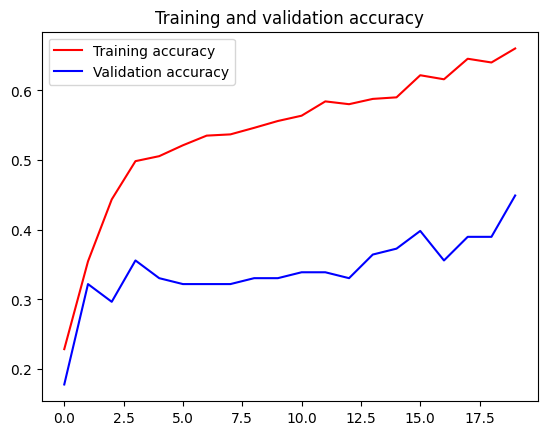

<Figure size 640x480 with 0 Axes>

In [ ]:
epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

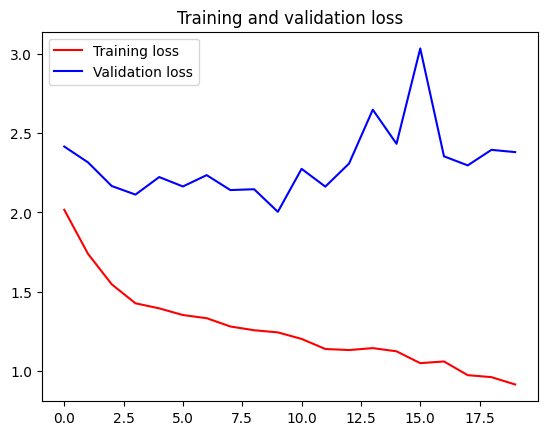

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()

plt.show()

In [ ]:
# Classifying the input image
from keras.preprocessing import image

class_labels = ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'sebrorrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

def predict_disease(image_path):
    # Load the image and preprocess it
    img = image.load_img(image_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize the image
    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class = class_labels[predicted_class_index]

    return predicted_class


image_path = "/content/ISIC_0025803.jpg"
predicted_disease = predict_disease(image_path)
print("Predicted Disease:", predicted_disease)


1/1 [==============================] - 0s 61ms/step
Predicted Disease: pigmented benign keratosis
